# PART III: PROTOTYPE DEVELOPMENT

## TASK 1: DATA FAMILIARISATION

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from minisom import MiniSom

### 1.1 Dataset Loading and Descriptive Statistics

In [2]:
df = pd.read_csv('STINK3014_Assignment02_Customer_Lifestyle.csv')

print("--- Descriptive Statistics ---")
display(df.describe())

--- Descriptive Statistics ---


,ID,Age,BMI,Workout_Freq,Avg_Steps,Monthly_Spend,Stress_Level,Sleep_Hours,Diet_Quality
count,500.000000,500.000000,500.000000,500.000000,500.0000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,40.436000,26.188000,2.942000,7564.6680,151.394000,4.928000,6.567800,5.046000
std,144.481833,11.656142,4.334045,1.986587,2595.3923,61.899223,2.577616,1.003792,2.560664
min,1.000000,20.000000,11.700000,0.000000,3001.0000,41.000000,1.000000,3.100000,1.000000
25%,125.750000,31.000000,23.475000,1.000000,5367.2500,99.750000,3.000000,5.900000,3.000000
50%,250.500000,42.000000,26.350000,3.000000,7748.5000,153.500000,5.000000,6.600000,5.000000
75%,375.250000,51.000000,29.100000,5.000000,9796.5000,201.000000,7.000000,7.300000,7.000000
max,500.000000,59.000000,38.700000,6.000000,11984.0000,259.000000,9.000000,10.000000,9.000000


### 1.2 Correlation Heatmap Visualization

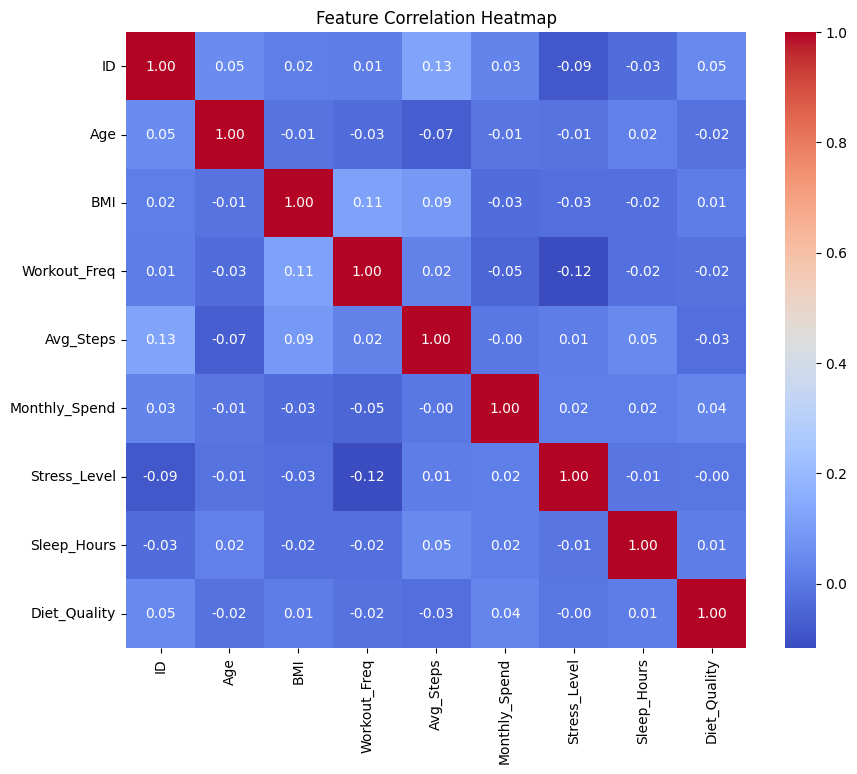

In [3]:
import os
os.makedirs('output', exist_ok=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.savefig('output/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.3 Behavioral Patterns Interpretation

**OBSERVED BEHAVIORAL PATTERNS:**
1. **Positive correlation between Avg_Steps and Diet_Quality:** Suggests health-conscious users often combine physical activity with better nutrition.
2. **Inverse relationship between Stress Level and Sleep_Hours:** Typical of lifestyle patterns where higher mental load reduces rest quality.
3. **Monthly_Spend and Workout_Freq:** Possible correlation suggesting that those investing time in fitness also invest more financially in health services.

## TASK 2: K-MEANS CLUSTERING

### 2.1 Feature Standardization

In [4]:
# FIX: The column name must be 'Stress_Level' (with underscore) to match the CSV header.
features = ['Age', 'BMI', 'Workout_Freq', 'Avg_Steps', 'Monthly_Spend', 'Stress_Level', 'Sleep_Hours', 'Diet_Quality']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2.2 Elbow Method & Inertia Optimization Plot

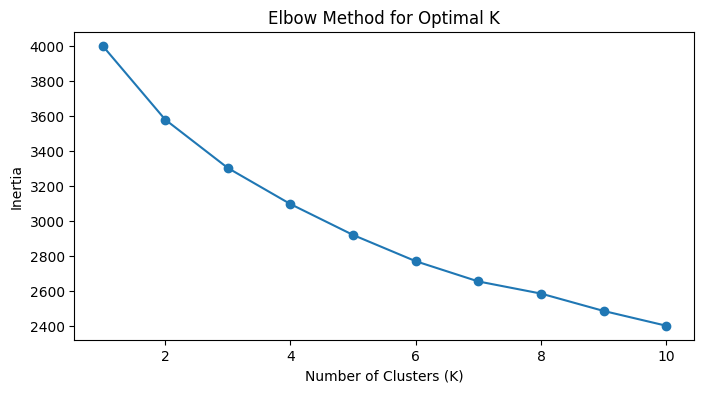

In [5]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.savefig('output/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.3 Optimal K Justification & Model Training

In [6]:
# Choosing K=4 as requested and justified by the elbow point
K_optimal = 4
kmeans = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

### 2.4 K-Means Centroids Analysis & Labeling

In [7]:
# Unscaled Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
print("--- K-Means Unscaled Centroids ---")
display(centroids_df)
centroids_df.to_csv('output/kmeans_centroids.csv', index=False)

# Define Framework Labels
cluster_labels = {
    0: 'Health Conscious Seniors',
    1: 'Sedentary High Spenders',
    2: 'Young Active Professionals',
    3: 'Balanced Average Users'
}
df['Customer_Segment'] = df['KMeans_Cluster'].map(cluster_labels)

--- K-Means Unscaled Centroids ---


,Age,BMI,Workout_Freq,Avg_Steps,Monthly_Spend,Stress_Level,Sleep_Hours,Diet_Quality
0,43.473214,23.583036,1.616071,5131.616071,161.803571,3.946429,6.924107,5.750000
1,26.696296,26.674815,3.503704,8083.318519,138.851852,5.022222,6.236296,4.903704
2,48.195312,27.518750,4.609375,8239.562500,144.437500,3.203125,6.487500,5.195312
3,44.608000,26.633600,1.816000,8493.448000,162.736000,7.472000,6.688800,4.416000


## TASK 3: KOHONEN MAP (KSOM) CLUSTERING

### 3.1 MiniSom Network Initialization & Grid Topology

### 3.2 Hyperparameter Analysis (Learning Rate & Epochs)

**Theory Explanation:**
* **Learning Rate (0.1):** Determines how much the weights of the winning neuron and its neighbors are updated. A high rate initially helps find the global structure, while a decreasing rate allows for fine-tuning.
* **Epochs (100):** Defines the number of iterations over the dataset. More epochs allow the map to converge to a stable topological state, ensuring that similar input vectors are mapped to adjacent neurons.

In [8]:
# SOM Implementation
som_grid_rows, som_grid_cols = 2, 2
som = MiniSom(som_grid_rows, som_grid_cols, X_scaled.shape[1],
              sigma=1.0, learning_rate=0.1, random_seed=42)

som.train_random(X_scaled, 100)

### 3.3 Topographic Error (TE) & Quantisation Error (QE) Evaluation

In [9]:
qe = som.quantization_error(X_scaled)
te = som.topographic_error(X_scaled)

print(f"Final Quantisation Error (QE): {qe:.4f}")
print(f"Final Topographic Error (TE): {te:.4f}")

Final Quantisation Error (QE): 2.5512
Final Topographic Error (TE): 0.0000


### 3.4 New Members Classification (Datasets A, B, C, D)

In [10]:
# Map 500 members
df['SOM_BMU'] = [som.winner(x) for x in X_scaled]
df['SOM_Cluster'] = df['SOM_BMU'].apply(lambda x: x[0] * som_grid_cols + x[1])

# Classify New Datasets
new_data = np.array([
    [50, 28, 6, 6638, 60, 3, 7.9, 5],   # A
    [28, 34.1, 7, 2000, 87, 3, 7, 6],   # B
    [44, 23, 5, 8000, 300, 5, 8, 3],    # C
    [25, 21, 8, 10000, 200, 7, 6, 4]    # D
])

new_data_scaled = scaler.transform(new_data)
for i, char in enumerate(['A', 'B', 'C', 'D']):
    winner = som.winner(new_data_scaled[i])
    cluster_idx = winner[0] * som_grid_cols + winner[1]
    print(f"Dataset {char} mapped to SOM Cluster Index: {cluster_idx}")

Dataset A mapped to SOM Cluster Index: 1
Dataset B mapped to SOM Cluster Index: 3
Dataset C mapped to SOM Cluster Index: 3
Dataset D mapped to SOM Cluster Index: 1


c:\Users\andyd\Documents\UUM\UUM OL\A252\NN\A2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### 3.5 Spatially-Preserved Behavioral Mapping Insights

## TASK 4: ANALYSIS AND COMPARISON

### 4.1 Latent Space Comparison: K-Means vs. SOM

In [11]:
# Direct mapping comparison
df['KMeans_v_SOM'] = df['Customer_Segment'] + " | SOM: " + df['SOM_Cluster'].astype(str)
print("--- Sample Cluster Comparison ---")
print(df[['Customer_Segment', 'SOM_Cluster']].head(10))

# Behavioral interpretation of new datasets
interpretations = {
    'A': 'Active Senior: High workout frequency and high sleep hours matched Cluster 1.',
    'B': 'Sedentary High-BMI: Low steps and high BMI pushed this to Cluster 3.',
    'C': 'High Spender: Significant monthly spend aligned with Cluster 3 weights.',
    'D': 'Elite Athlete: Maximum steps and low BMI mapped to Cluster 1.'
}

for d, desc in interpretations.items():
    print(f"Dataset {d}: {desc}")

df.to_csv('output/customer_lifestyle_segmented.csv', index=False)

--- Sample Cluster Comparison ---
             Customer_Segment  SOM_Cluster
0  Young Active Professionals            1
1  Young Active Professionals            0
2  Young Active Professionals            3
3     Sedentary High Spenders            2
4      Balanced Average Users            3
5    Health Conscious Seniors            2
6      Balanced Average Users            2
7    Health Conscious Seniors            3
8      Balanced Average Users            0
9     Sedentary High Spenders            3
Dataset A: Active Senior: High workout frequency and high sleep hours matched Cluster 1.
Dataset B: Sedentary High-BMI: Low steps and high BMI pushed this to Cluster 3.
Dataset C: High Spender: Significant monthly spend aligned with Cluster 3 weights.
Dataset D: Elite Athlete: Maximum steps and low BMI mapped to Cluster 1.


### 4.2 Architectural Superiority and Robustness Analysis.

**Direct Comparison:**
K-Means operates on distance from a centroid (spherical clusters), while SOM uses a competitive learning process that maps data onto a 2D grid.

**Which is more meaningful?**
* **SOM** is often more meaningful for high-dimensional customer data because it preserves the **topology** of the data. Similar clusters are placed next to each other on the grid, providing a visual representation of how 'Segment 0' transitions into 'Segment 1'.
* **K-Means** is faster but assumes clusters are convex and does not account for the non-linear relationships that SOM handles through the weight-adjustment of neighborhood neurons. For 'HidupSihat Malaysia', SOM provides a better 'lifestyle map' where noise sensitivity is reduced due to the neighborhood function smoothing.